In [ ]:
import mediapipe as mp



In [3]:
from mediapipe import solutions
from mediapipe.framework.formats import landmark_pb2
import numpy as np


def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  # Loop through the detected poses to visualize.
  for idx in range(len(pose_landmarks_list)):
    pose_landmarks = pose_landmarks_list[idx]

    # Draw the pose landmarks.
    pose_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
    pose_landmarks_proto.landmark.extend([
      landmark_pb2.NormalizedLandmark(x=landmark.x, y=landmark.y, z=landmark.z) for landmark in pose_landmarks
    ])
    solutions.drawing_utils.draw_landmarks(
      annotated_image,
      pose_landmarks_proto,
      solutions.pose.POSE_CONNECTIONS,
      solutions.drawing_styles.get_default_pose_landmarks_style())
  return annotated_image

In [4]:
from utils import get_all_measurements

In [38]:

import cv2
import matplotlib.pyplot as plt

def show_image(PATH):
    img = cv2.imread(PATH)
    image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display using matplotlib
    plt.imshow(image_rgb)
    plt.axis('off')  # Hide axes
    plt.title("Image brute")
    plt.show()


In [39]:
#Then download an off-the-shelf model bundle. Check out the MediaPipe documentation for more information about this model bundle.
# !wget -O pose_landmarker.task -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task

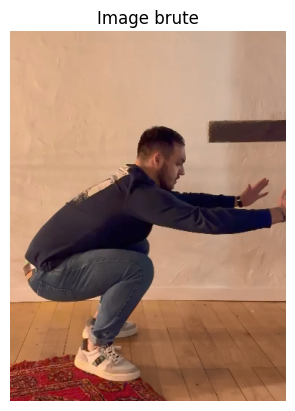

In [40]:
PATH = "data/reference/descente-fin.png"
show_image(PATH)

In [41]:
# extraire les points via mediapipe
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

def show_skeleton(PATH):
    img = cv2.imread(PATH)
    image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # # Display using matplotlib
    # plt.imshow(image_rgb)
    # plt.axis('off')  # Hide axes
    # plt.title("Descente Casser la parallèle")
    # plt.show()


    # STEP 2: Create an PoseLandmarker object.
    base_options = python.BaseOptions(model_asset_path='pose_landmarker_heavy.task')
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        output_segmentation_masks=True)
    detector = vision.PoseLandmarker.create_from_options(options)

    # STEP 3: Load the input image.
    image = mp.Image.create_from_file(PATH)

    # STEP 4: Detect pose landmarks from the input image.
    detection_result = detector.detect(image)
    landmarks = detection_result.pose_landmarks

    if detection_result.pose_landmarks:
        landmarks = np.array([[landmark.x, landmark.y, landmark.z] for landmark in detection_result.pose_landmarks[0]])

        
    res = get_all_measurements(landmarks)

    # STEP 5: Process the detection result. In this case, visualize it.
    annotated_image = draw_landmarks_on_image(img, detection_result)
    # cv2_imshow(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))

    # Display using matplotlib
    plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))
    plt.axis('off')  # Hide axes
    plt.title("Detection Mediapipe")
    plt.show()

In [42]:
# check alignement pieds/épaules

# get angles back, right knee, left knee

# check 

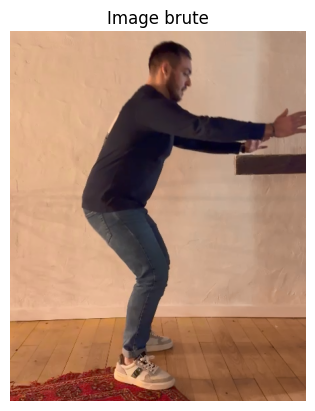

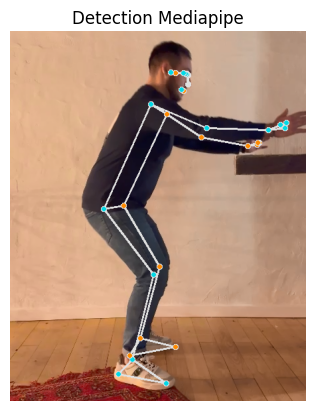

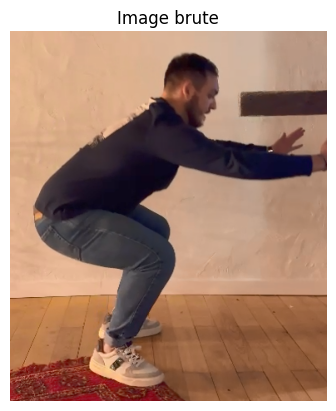

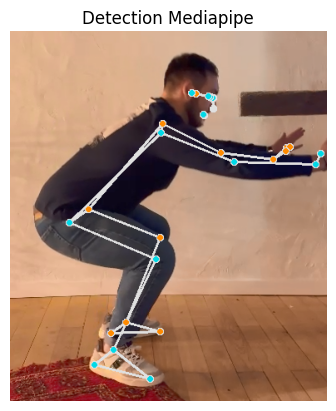

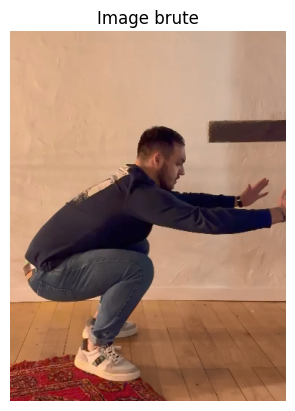

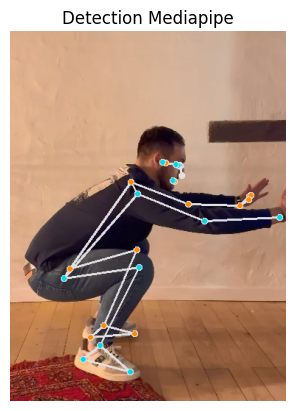

In [43]:
PATH = "data/reference/descente-1.png"
show_image(PATH)
show_skeleton(PATH)
PATH = "data/reference/descente-2.png"
show_image(PATH)
show_skeleton(PATH)
PATH = "data/reference/descente-fin.png"
show_image(PATH)
show_skeleton(PATH)

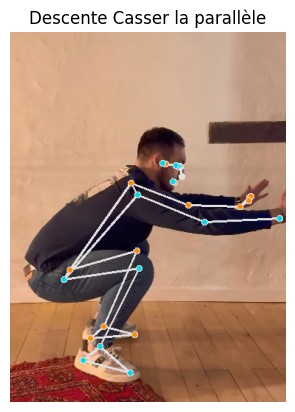

In [33]:
show_skeleton(PATH)

In [ ]:
import cv2
import mediapipe as mp

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, 
                    model_complexity=1, 
                    enable_segmentation=False, 
                    min_detection_confidence=0.5)

# Initialize drawing utils
mp_drawing = mp.solutions.drawing_utils

# Open the input video
video_path = "data/reference/video.mp4"
cap = cv2.VideoCapture(video_path)

# Get video properties
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Define output video writer
out = cv2.VideoWriter(
    "output_video.mp4",
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Convert the frame to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Process the frame with MediaPipe Pose
    results = pose.process(frame_rgb)

    # Draw the pose annotation on the frame
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            results.pose_landmarks,
            mp_pose.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=2),
            mp_drawing.DrawingSpec(color=(255, 0, 0), thickness=2)
        )

    # Write the frame to the output video
    out.write(frame)

    # Optional: display live (comment out if you just want to save)
    cv2.imshow('Pose Detection', frame)
    if cv2.waitKey(1) & 0xFF == 27:  # Press 'Esc' to exit early
        break
    
# Release everything
cap.release()
out.release()
cv2.destroyAllWindows()